[2026-07-23 18:05:57] [info     ] 计算分数                           end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-23 18:05:57] [info     ] 已加载模型                          device=cuda params=321892 path=stock_model.json
[2026-07-23 18:05:57] [info     ] 构建测试集并预测                       end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-23 18:23:39] [info     ] infer 集构建完成                    elapsed=1061.85 n_dates=242 n_feat=48 n_stocks=1206 samples=290712
[2026-07-23 18:23:44] [info     ] 分数构建完成                         days=242 instruments=1206 rows=241770
        date instrument     score
0 2024-01-02  600556.SH  0.506922
1 2024-01-02  600572.SH  0.879931
2 2024-01-02  600776.SH  0.777613
3 2024-01-02  600821.SH  0.835460
4 2024-01-02  600835.SH  0.655458
[2026-07-23 18:23:44] [info     ] 开始评估分数
[2026-07-23 18:23:44] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-23 18:23:44] [info     ] bigalpha_eval.v4 开始运行 ..

时段,IC
2024-01-15~2024-02-08,0.0176
2024-09-24~2024-10-08,0.0682

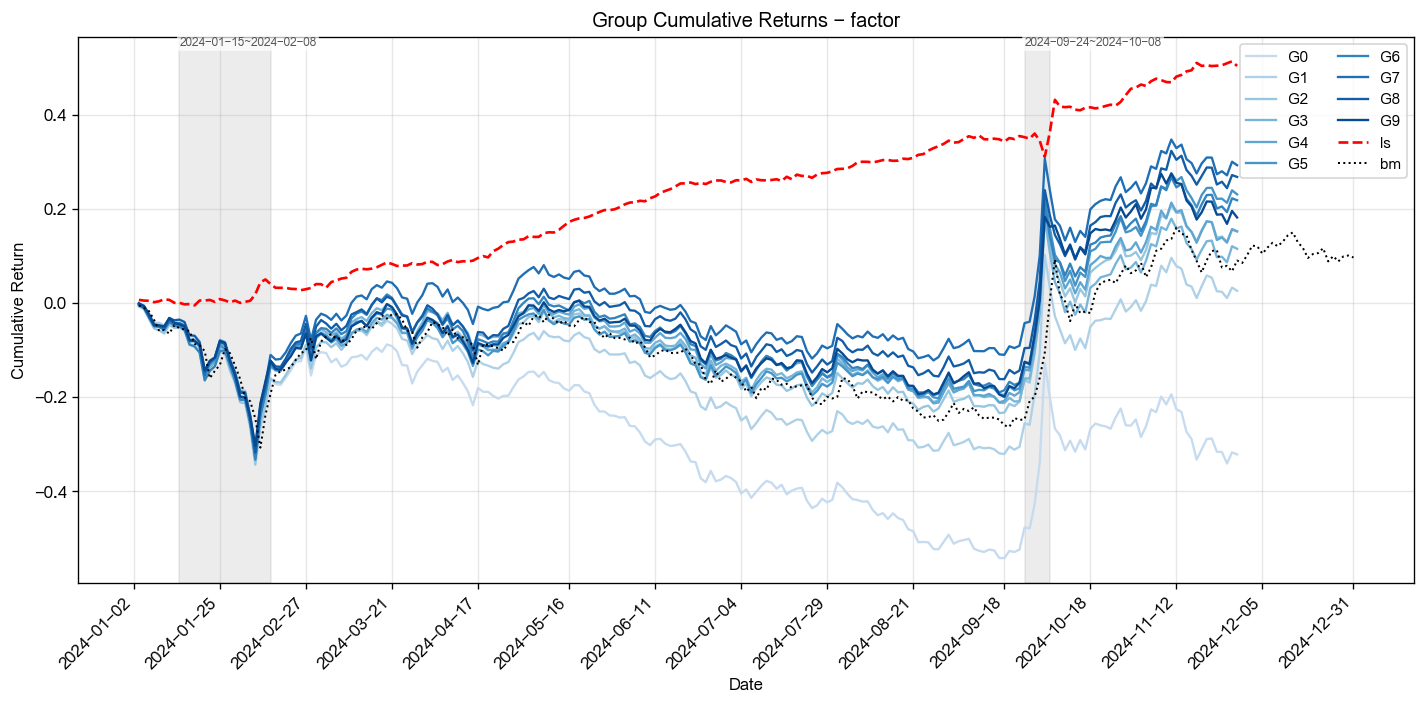
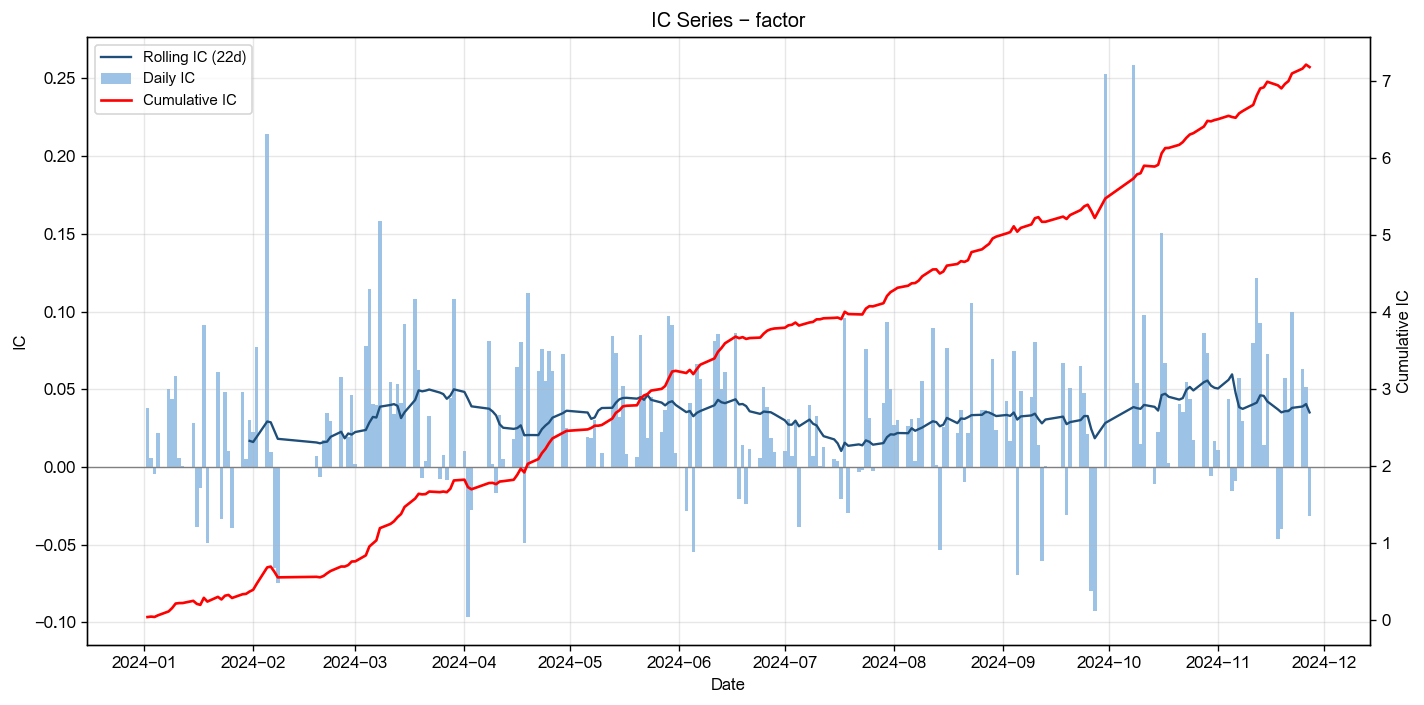
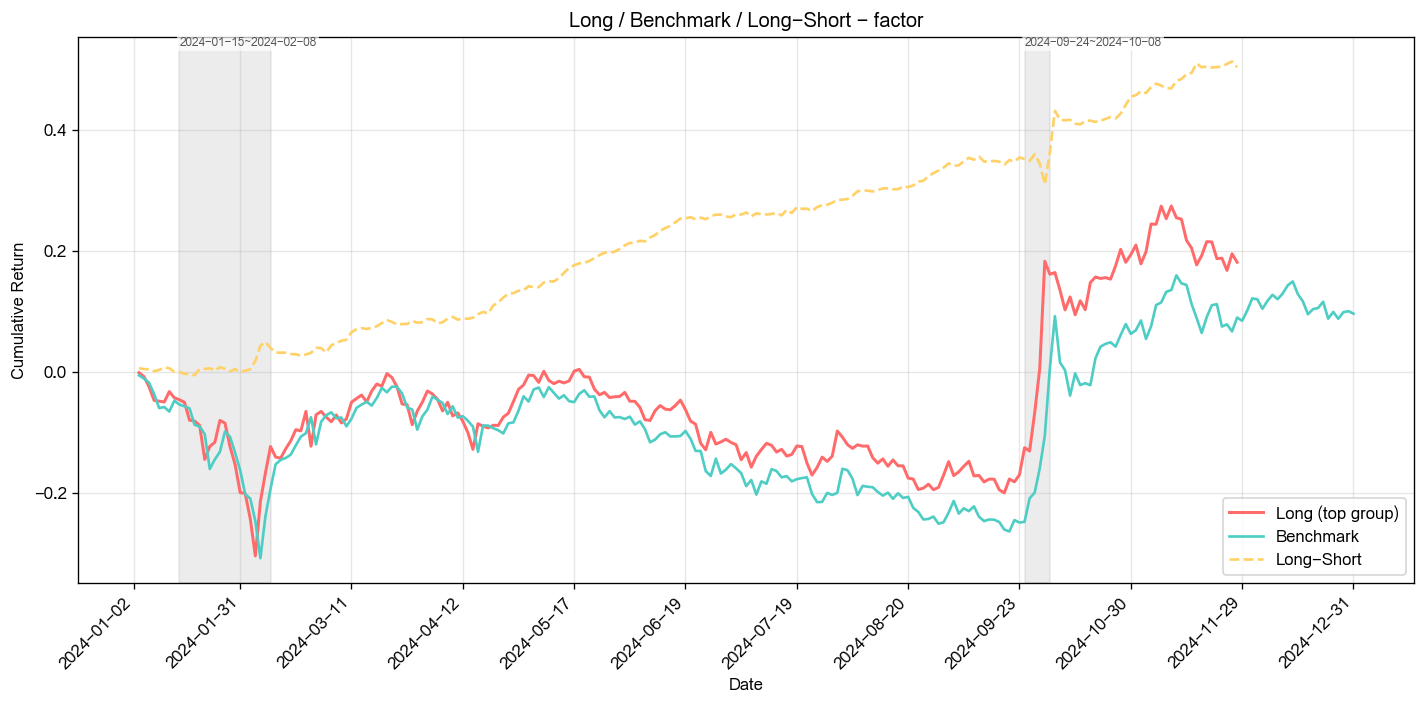
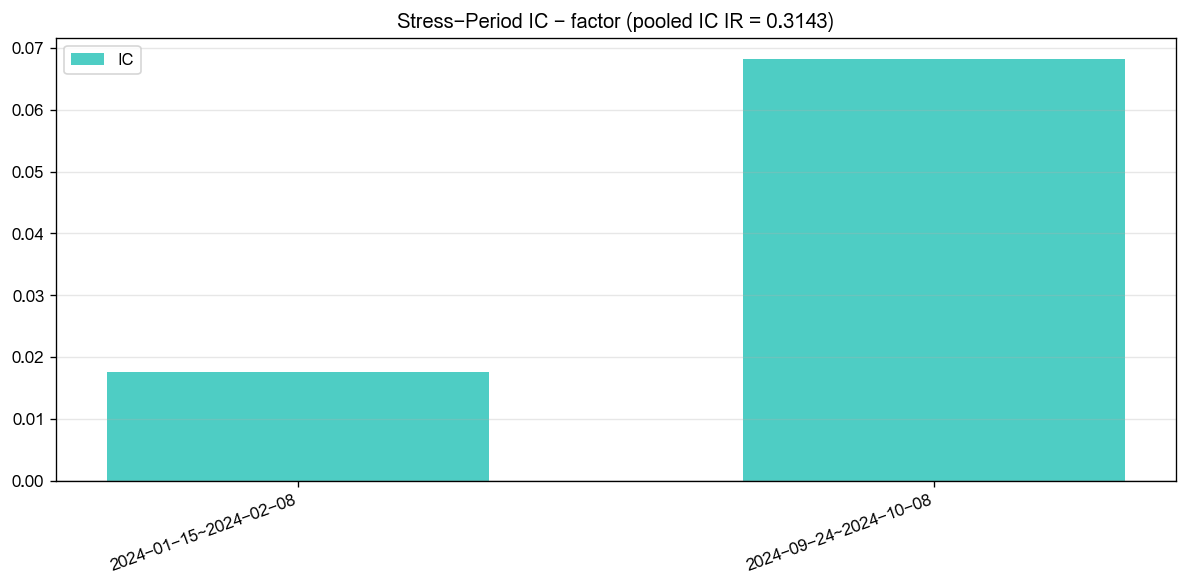
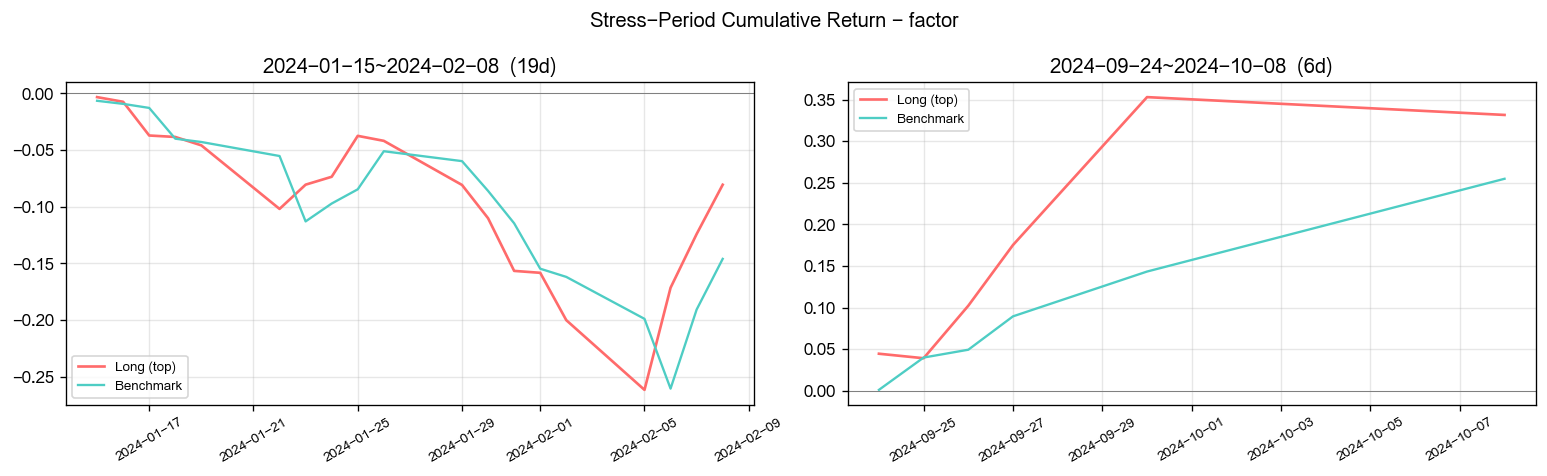

[2026-07-23 18:24:07] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-07-23 18:24:07] [warning  ] 返回的Outputs实例(size=35186421) 大于 64K, 将不会被缓存
[2026-07-23 18:24:07] [info     ] bigalpha_eval.v4 运行完成 [23.123s].


In [2]:


import os
import importlib
import GRU_modelsave_train
importlib.reload(GRU_modelsave_train)
from GRU_modelsave_train import (
    MODEL_PATH, BATCH, N_FEAT_TOTAL, StockGRU,
    build_dataset, pool, load_model,
)
import numpy as np
import pandas as pd
import dai
import torch
import structlog

logger = structlog.get_logger()


def main(datasources, start_date, end_date):
    """加载模型, 在测试区间上推理打分。返回 DataFrame[date, instrument, score]。"""
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}。请先运行 GRU_modelsave_train.py 训练。")

    model, mean, std = load_model(MODEL_PATH, device=device)
    stats = (mean.cpu().numpy(), std.cpu().numpy())
    model.eval()

    logger.info("已加载模型", path=MODEL_PATH, device=str(device),
                params=sum(p.numel() for p in model.parameters()))

    logger.info("构建测试集并预测", start=str(start_date), end=str(end_date))
    Xte, _, idx_df, _ = build_dataset(
        table, start_date, end_date, "infer",
        pool(start_date, end_date), stats,
    )
    assert idx_df is not None, "推理阶段 idx_df 为空"

    preds = []
    with torch.no_grad():
        for i in range(0, len(idx_df), BATCH):
            xb = torch.from_numpy(Xte[i:i + BATCH]).to(device)
            preds.append(model(xb, task=2).cpu().numpy())

    idx_df["score"] = np.concatenate(preds).astype(np.float64)

    stk = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    result = (
        pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
        .reset_index(drop=True)
    )
    logger.info("分数构建完成", rows=len(result),
                days=result["date"].nunique(),
                instruments=result["instrument"].nunique())
    return result


if __name__ == "__main__":
    from bigmodule import M

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"

    logger.info("计算分数", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    logger.info("开始评估分数")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)